In [1]:
import json
from typing import Sequence

import agama
import gc_utils
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut

In [2]:
sim = "m12b"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

In [24]:
z_lim = 2
n_bins = 20
r_lim = 10
snap = 600

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
snap_lim_lst = [46, 46, 46, 46, 102]
# sim_lst = ["m12i"]
# snap_lim_lst = [46]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

grad_dict = {sim: {} for sim in sim_lst}

for j, sim in enumerate(sim_lst):
    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    part = gc_utils.open_snapshot(snap, fire_dir, species=["star"])

    pos_cyl = part["star"].prop("host.distance.cylindrical")

    r_msk = pos_cyl[:, 0] <= r_lim
    z_msk = np.abs(pos_cyl[:, 2]) <= z_lim

    age_msk = part["star"].prop("age")[r_msk & z_msk]
    cyl_msk = pos_cyl[r_msk & z_msk]

    r_bins = np.linspace(0, r_lim, n_bins + 1)
    r_centres = np.array([(r_bins[i - 1] + r_bins[i]) / 2 for i in range(1, len(r_bins))])

    age_lst = []
    n_bins = len(r_bins) - 1
    for i in range(n_bins):
        r_min = r_bins[i]
        r_max = r_bins[i + 1]
        r_centre = (r_max + r_min) / 2

        r_msk = (cyl_msk[:, 0] > r_min) & (cyl_msk[:, 0] <= r_max)
        age_bin = age_msk[r_msk]

        # avg_age = np.mean(age_bin)
        avg_age = np.median(age_bin)
        age_lst.append(avg_age)

    grad_dict[sim]["r"] = r_centres
    grad_dict[sim]["age"] = age_lst

#     plt.plot(r_centres, age_lst, c=colors[j], label=sim)

# plt.xlabel("Radius (kpc) (|z| <= 1 kpc)")
# plt.ylabel("Stellar Age (Gyr)")

# plt.xlim(0, 10)
# plt.ylim(2, 9)

# plt.legend()

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:21<00:00, 21.31s/it]


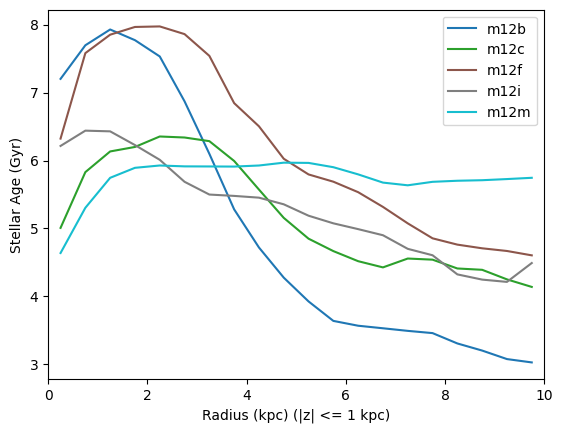

In [25]:
for j, sim in enumerate(sim_lst):
    plt.plot(grad_dict[sim]["r"], grad_dict[sim]["age"], c=colors[j], label=sim)

plt.xlabel("Radius (kpc) (|z| <= 1 kpc)")
plt.ylabel("Stellar Age (Gyr)")

plt.xlim(0, 10)
# plt.ylim(2, 9)

plt.legend()

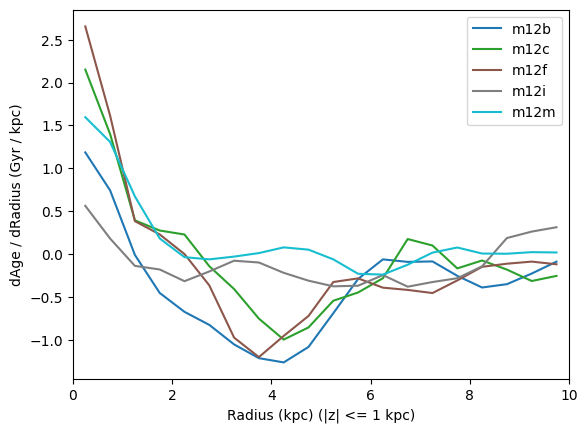

In [23]:
for j, sim in enumerate(sim_lst):
    grad = np.gradient(grad_dict[sim]["age"], grad_dict[sim]["r"])
    plt.plot(grad_dict[sim]["r"], grad, c=colors[j], label=sim)

plt.xlabel("Radius (kpc) (|z| <= 1 kpc)")
plt.ylabel("dAge / dRadius (Gyr / kpc)")

plt.xlim(0, 10)
# plt.ylim(2, 9)

plt.legend()

In [6]:
def get_density(part, snap, halt, ptype="star", rlim=3, temp_lim=None):
    volume = (4 * np.pi / 3) * (r_lim**3)

    main_halo = sim_codes[sim]["halo"]
    halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
    halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]

    part_dist = ut.coordinate.get_distances(
        part[ptype]["position"],
        halt["position"][halo_tidx],
        part.info["box.length"],
        part.snapshot["scalefactor"],
        True,
    )  # [kpc physical]

    part_msk = part_dist <= rlim

    if temp_lim is not None:
        temp_msk = np.log10(part[ptype]["temperature"]) <= temp_lim
        part_mass = np.sum(part[ptype]["mass"][part_msk & temp_msk])
    else:
        part_mass = np.sum(part[ptype]["mass"][part_msk])

    part_dens = part_mass / volume

    return part_dens

In [7]:
def get_sfr(part, snap, halt, rlim=3):
    main_halo = sim_codes[sim]["halo"]
    halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
    halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]

    gas_dist = ut.coordinate.get_distances(
        part["gas"]["position"],
        halt["position"][halo_tidx],
        part.info["box.length"],
        part.snapshot["scalefactor"],
        True,
    )  # [kpc physical]

    gas_msk = gas_dist <= rlim
    sfr = np.nansum(part["gas"]["sfr"][gas_msk])  # instantaneous star formation rate [M_sun / yr]

    star_dist = ut.coordinate.get_distances(
        part["star"]["position"],
        halt["position"][halo_tidx],
        part.info["box.length"],
        part.snapshot["scalefactor"],
        True,
    )  # [kpc physical]

    star_msk = star_dist <= rlim
    star_mass = np.sum(part["star"]["mass"][star_msk])
    ssfr = sfr / star_mass

    return sfr, ssfr

In [8]:
sim_dict = {sim: {} for sim in sim_lst}

for j, sim in enumerate(sim_lst):
    halt = gc_utils.get_halo_tree(sim, sim_dir)

    snap_lim = snap_lim_lst[j]
    snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].values

    star_dens_lst = []
    gas_dens_lst = []
    cold_gas_dens_lst = []
    sfr_lst = []
    ssfr_lst = []
    for snap in snap_lst:
        part = gc_utils.open_snapshot(snap, fire_dir, species=["star", "gas"])
        star_dens_lst.append(get_density(part, snap, halt, ptype="star", rlim=3))
        gas_dens_lst.append(get_density(part, snap, halt, ptype="gas", rlim=3))
        cold_gas_dens_lst.append(get_density(part, snap, halt, ptype="gas", rlim=3, temp_lim=4.5))

        sfr, ssfr = get_sfr(part, snap, halt, rlim=3)
        sfr_lst.append(sfr)
        ssfr_lst.append(ssfr)

    sim_dict[sim]["star_dens"] = np.array(star_dens_lst)
    sim_dict[sim]["gas_dens"] = np.array(gas_dens_lst)
    sim_dict[sim]["cold_gas_dens"] = np.array(cold_gas_dens_lst)
    sim_dict[sim]["sfr"] = np.array(sfr_lst)
    sim_dict[sim]["ssfr"] = np.array(ssfr_lst)

Retrieving Halo Tree.....................:   0%|                                                                                | 0/1 [00:09<?, ?it/s]


KeyboardInterrupt: 

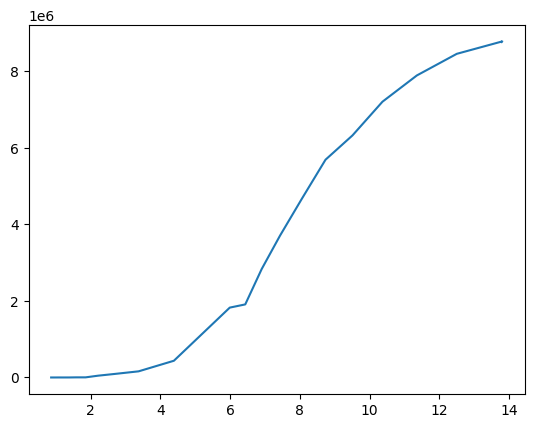

In [ ]:
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].values

plt.plot(time_lst, star_dens_lst)
# plt.yscale("log")

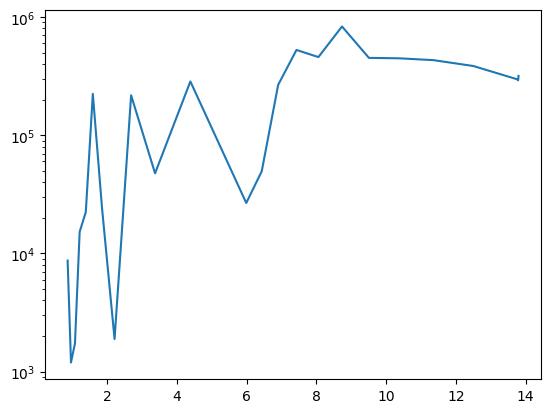

In [ ]:
# plt.plot(time_lst, star_dens_lst)
# plt.plot(time_lst, gas_dens_lst)
plt.plot(time_lst, cold_gas_dens_lst)
plt.yscale("log")

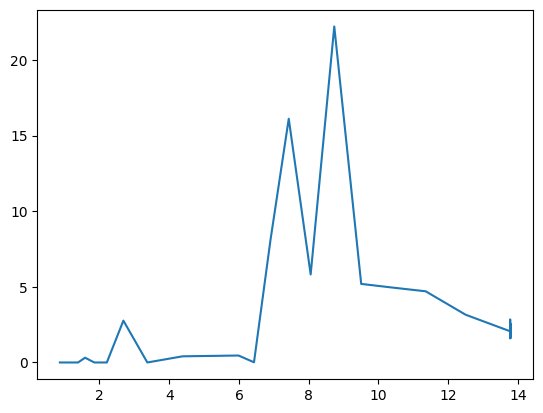

In [ ]:
i = 0
plt.plot(time_lst[i:], sim_dict[sim]["sfr"][i:])
# plt.yscale("log")